# 🛒 Análisis de la Cesta de la Compra y Sistema de Recomendación para E-commerce

**Universidad Internacional de La Rioja (UNIR)**  
**Máster Universitario en Big Data y Ciencia de Datos**

| | |
|---|---|
| **Autores** | Franco Adrián Raffaele · Lucía Pérez Aída · Saioa Cuadrado Recio |
| **Tutor** | Igor Pascual Sagastagotia |
| **Fecha** | Junio 2025 |

---

## 📋 Descripción del proyecto

Este notebook implementa un pipeline completo de **Market Basket Analysis** sobre el dataset UCI Online Retail, con el objetivo de construir un sistema de recomendación de productos basado en reglas de asociación.

### Pipeline (metodología CRISP-DM)
| Fase | Descripción | Objetivo SMART |
|------|-------------|---------------|
| 1 | Carga e inspección del dataset | — |
| 2 | Preprocesamiento y limpieza | OE1: reducir ruido ≥ 20% |
| 3 | Análisis exploratorio (EDA) | OE2: caracterizar el dataset |
| 4 | Modelado: Apriori y FP-Growth | OE3, OE4, OE5 |
| 5 | Motor de recomendación | OE6: confianza media > 40% |
| 6 | Simulación de impacto en AOV | OE7: incremento AOV 10–25% |

### Requisitos previos
```bash
pip install -r requirements.txt
```

### Dataset
Descargar desde: https://archive.ics.uci.edu/dataset/352/online+retail  
Guardar como `data/Online Retail.xlsx`

---


## ⚙️ 0. Instalación de dependencias

In [1]:
# Solo ejecutar si no están instaladas las librerías
# !pip install -r requirements.txt

# Verificación de versiones
import sys
print(f"Python: {sys.version}")

import pandas as pd
import numpy as np
import matplotlib
import mlxtend
import seaborn

print(f"pandas:    {pd.__version__}")
print(f"numpy:     {np.__version__}")
print(f"mlxtend:   {mlxtend.__version__}")
print(f"matplotlib:{matplotlib.__version__}")
print(f"seaborn:   {seaborn.__version__}")
print("\n✅ Todas las librerías disponibles.")

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas:    2.1.4
numpy:     1.26.4
mlxtend:   0.23.1
matplotlib:3.8.2
seaborn:   0.13.2

✅ Todas las librerías disponibles.


## 📦 1. Importaciones y configuración global

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import os
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# ── Carpeta de salida para CSV (Power BI) ────────────────────────────────────
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('figures', exist_ok=True)

# ── Paleta de colores corporativa ─────────────────────────────────────────────
BLUE   = '#185FA5'
TEAL   = '#0F6E56'
AMBER  = '#854F0B'
CORAL  = '#993C1D'
PURPLE = '#534AB7'
GRAY   = '#5F5E5A'
LIGHT_BLUE = '#B5D4F4'

# ── Estilo global de gráficos ─────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'figure.facecolor':   'white',
    'axes.facecolor':     '#FAFAFA',
    'figure.dpi':         120,
})

print("✅ Configuración cargada correctamente.")
print(f"📁 Carpeta de outputs: {os.path.abspath(OUTPUT_DIR)}")

✅ Configuración cargada correctamente.
📁 Carpeta de outputs: C:\Users\franc\Desktop\market-basket-analysis\outputs


## 📂 2. Carga e inspección inicial del dataset

**Fuente:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/352/online+retail  
**Referencia APA:** Chen, D. (2015). *Online Retail* [Conjunto de datos]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BW33


In [4]:
# ── Carga del dataset ─────────────────────────────────────────────────────────
DATASET_PATH = 'data/Online Retail.xlsx'

df = pd.read_excel(DATASET_PATH, dtype={'CustomerID': str})

print("=" * 55)
print("INSPECCIÓN INICIAL DEL DATASET")
print("=" * 55)
print(f"  Filas:             {df.shape[0]:,}")
print(f"  Columnas:          {df.shape[1]}")
print(f"  Rango de fechas:   {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"  Países únicos:     {df['Country'].nunique()}")
print(f"  Clientes únicos:   {df['CustomerID'].nunique():,}")
print(f"  Productos únicos:  {df['Description'].nunique():,}")
print("=" * 55)
df.head()

INSPECCIÓN INICIAL DEL DATASET
  Filas:             541,909
  Columnas:          8
  Rango de fechas:   2010-12-01 08:26:00 → 2011-12-09 12:50:00
  Países únicos:     38
  Clientes únicos:   4,372
  Productos únicos:  4,223


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [5]:
# ── Análisis de calidad de datos ──────────────────────────────────────────────
print("VALORES NULOS POR COLUMNA")
print("-" * 35)
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
calidad = pd.DataFrame({'Nulos': nulos, '% del total': pct})
print(calidad[calidad['Nulos'] > 0].to_string())
print()

# Detectar devoluciones
devoluciones = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Facturas de devolución (prefijo 'C'): {devoluciones['InvoiceNo'].nunique():,}")
print(f"Registros con Quantity <= 0:          {(df['Quantity'] <= 0).sum():,}")
print(f"Registros con UnitPrice <= 0:         {(df['UnitPrice'] <= 0).sum():,}")

VALORES NULOS POR COLUMNA
-----------------------------------
              Nulos  % del total
Description    1454         0.27
CustomerID   135080        24.93

Facturas de devolución (prefijo 'C'): 3,836
Registros con Quantity <= 0:          10,624
Registros con UnitPrice <= 0:         2,517


## 🧹 3. Preprocesamiento de datos

**Objetivo OE1:** Reducir el ruido de los datos en al menos un **20%** respecto al volumen original,
eliminando devoluciones, valores nulos y registros inconsistentes.


In [6]:
# ── Pipeline de limpieza paso a paso ─────────────────────────────────────────
registros_originales = len(df)
log_limpieza = []

# PASO 1: Eliminar nulos en Description y CustomerID
df.dropna(subset=['Description', 'CustomerID'], inplace=True)
log_limpieza.append(('Eliminar nulos (Description/CustomerID)', len(df)))

# PASO 2: Eliminar devoluciones (factura empieza por 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
log_limpieza.append(('Eliminar devoluciones', len(df)))

# PASO 3: Eliminar Quantity y UnitPrice negativos o nulos
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
log_limpieza.append(('Eliminar valores negativos', len(df)))

# PASO 4: Normalizar descripción
df['Description'] = df['Description'].str.strip().str.upper()
df['InvoiceNo']   = df['InvoiceNo'].astype(str)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
log_limpieza.append(('Normalizar texto y tipos', len(df)))

# ── Resumen de limpieza ───────────────────────────────────────────────────────
print("=" * 55)
print("RESULTADO DEL PIPELINE DE LIMPIEZA")
print("=" * 55)
print(f"  Registros originales:      {registros_originales:,}")
for paso, n in log_limpieza:
    print(f"  Tras '{paso}': {n:,}")

registros_limpios = len(df)
reduccion = (registros_originales - registros_limpios) / registros_originales * 100

print(f"\n  Reducción total de ruido:  {reduccion:.1f}%")
print(f"  OE1 cumplido (> 20%):      {'✅ SÍ' if reduccion > 20 else '❌ NO'}")
print("=" * 55)

RESULTADO DEL PIPELINE DE LIMPIEZA
  Registros originales:      541,909
  Tras 'Eliminar nulos (Description/CustomerID)': 406,829
  Tras 'Eliminar devoluciones': 397,924
  Tras 'Eliminar valores negativos': 397,884
  Tras 'Normalizar texto y tipos': 397,884

  Reducción total de ruido:  26.6%
  OE1 cumplido (> 20%):      ✅ SÍ


In [7]:
# ── Construcción de la matriz transaccional (UK) ─────────────────────────────
# Filtrar por Reino Unido (91% del volumen)
df_uk = df[df['Country'] == 'United Kingdom'].copy()
df_uk['Revenue'] = df_uk['Quantity'] * df_uk['UnitPrice']

print(f"Transacciones UK: {len(df_uk):,} registros")
print(f"Facturas únicas:  {df_uk['InvoiceNo'].nunique():,}")
print(f"Productos únicos: {df_uk['Description'].nunique():,}")

# Construir cesta por factura
basket = (df_uk
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

# Convertir a binario (0/1)
basket_encoded = basket.applymap(lambda x: 1 if x >= 1 else 0)

densidad = basket_encoded.values.mean() * 100
print(f"\nDimensiones de la matriz: {basket_encoded.shape[0]:,} transacciones × {basket_encoded.shape[1]:,} productos")
print(f"Densidad de la matriz:    {densidad:.2f}%")
print("\n✅ Matriz transaccional lista para modelado.")

Transacciones UK: 354,321 registros
Facturas únicas:  16,646
Productos únicos: 3,833

Dimensiones de la matriz: 16,646 transacciones × 3,833 productos
Densidad de la matriz:    0.54%

✅ Matriz transaccional lista para modelado.


## 📊 4. Análisis Exploratorio de Datos — EDA

**Objetivo OE2:** Identificar los 20 productos más vendidos, la distribución geográfica
y los patrones de estacionalidad mensual.


C:\Users\franc\Desktop\market-basket-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\franc\Desktop\market-basket-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\franc\Desktop\market-basket-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


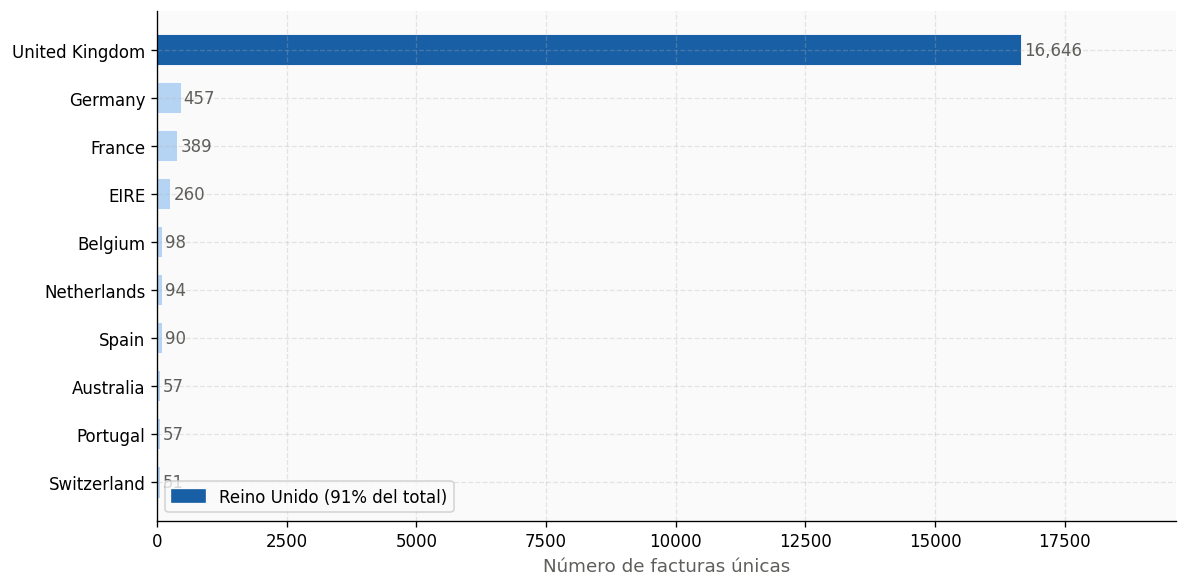

✅ Figura 2 guardada en figures/fig2_paises.png


In [8]:
# ── FIGURA 2: Distribución por país ──────────────────────────────────────────
top_countries = (df.groupby('Country')['InvoiceNo']
                 .nunique()
                 .sort_values(ascending=False)
                 .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [BLUE if c == 'United Kingdom' else LIGHT_BLUE for c in top_countries.index]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(val + 60, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, color=GRAY)

ax.set_xlabel('Número de facturas únicas', fontsize=11, color=GRAY)
ax.set_xlim(0, top_countries.max() * 1.18)
patch = mpatches.Patch(color=BLUE, label='Reino Unido (91% del total)')
ax.legend(handles=[patch], fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig2_paises.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 2 guardada en figures/fig2_paises.png")

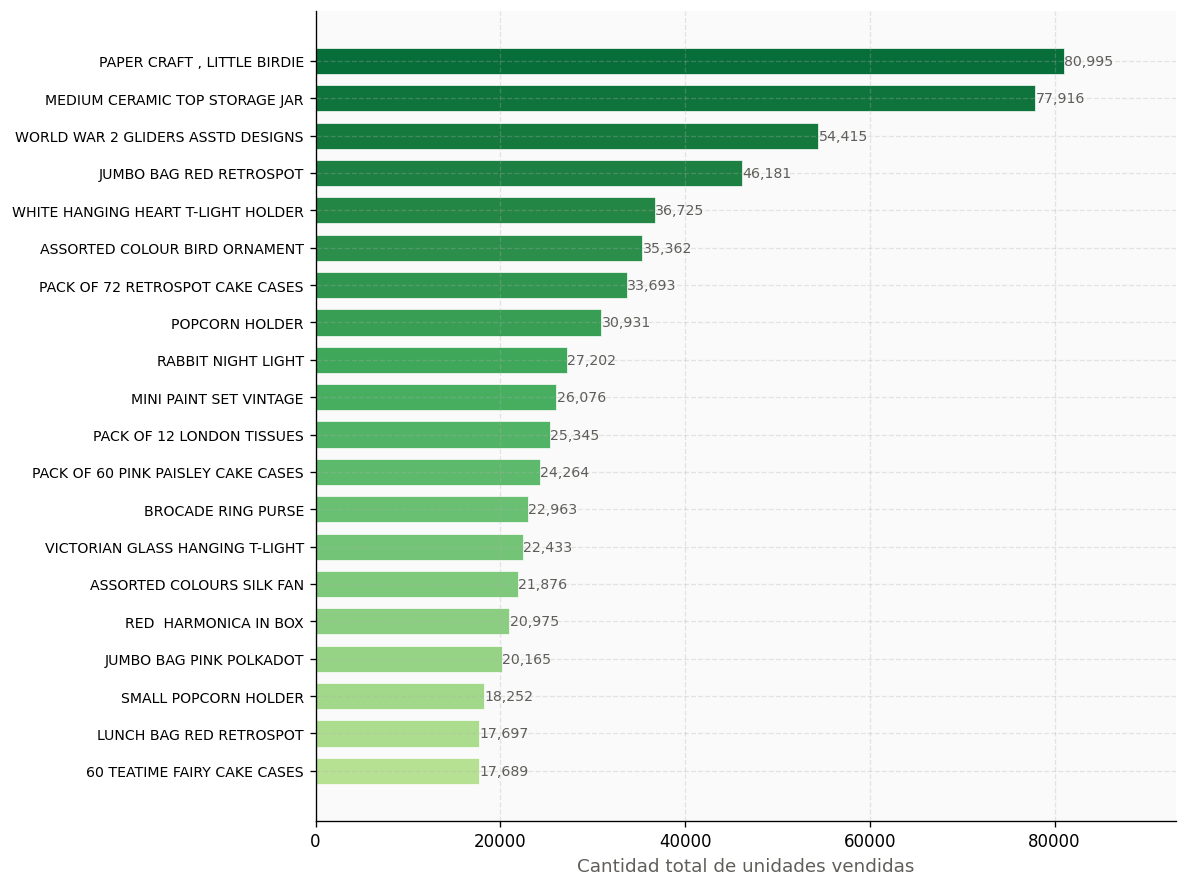

✅ Figura 3 guardada en figures/fig3_productos.png


In [9]:
# ── FIGURA 3: Top 20 productos más vendidos ──────────────────────────────────
top_products = (df.groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(10, 7.5))
greens = plt.cm.YlGn(np.linspace(0.35, 0.85, len(top_products)))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1],
               color=greens, edgecolor='white', linewidth=0.4, height=0.7)

for bar, val in zip(bars, top_products.values[::-1]):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8.5, color=GRAY)

ax.set_xlabel('Cantidad total de unidades vendidas', fontsize=11, color=GRAY)
ax.tick_params(axis='y', labelsize=8.5)
ax.set_xlim(0, top_products.max() * 1.15)
plt.tight_layout()
plt.savefig('figures/fig3_productos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 3 guardada en figures/fig3_productos.png")

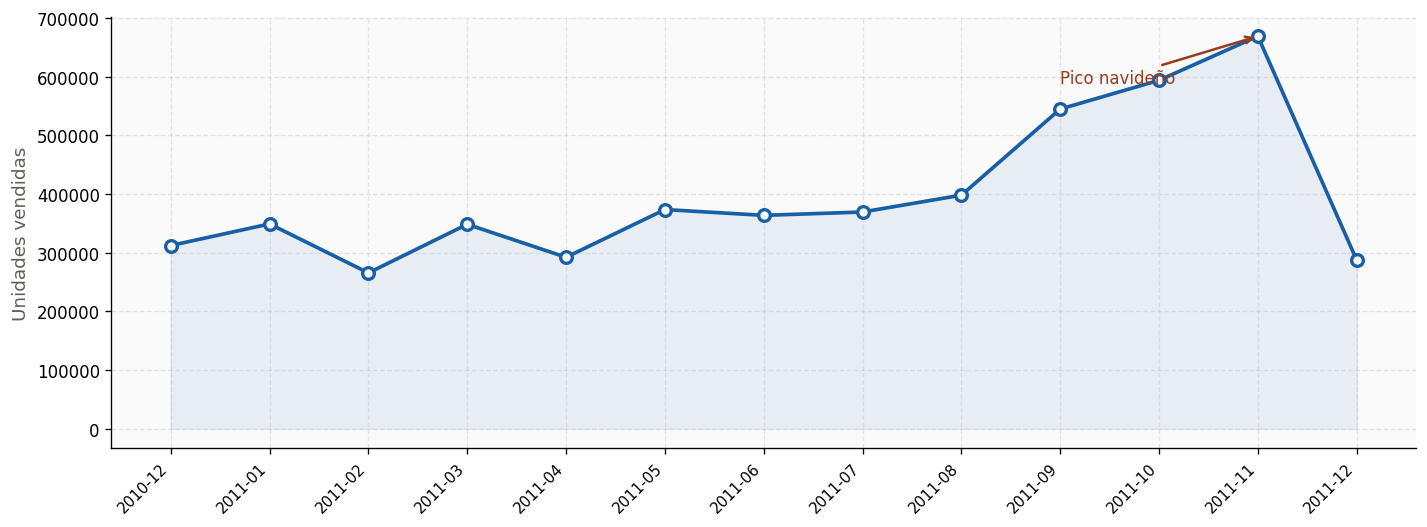

✅ Figura 4 guardada en figures/fig4_temporal.png


In [10]:
# ── FIGURA 4: Evolución mensual de ventas ────────────────────────────────────
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales   = df.groupby('YearMonth')['Quantity'].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(monthly_sales))
ax.plot(x, monthly_sales.values, color=BLUE, linewidth=2.2,
        marker='o', markersize=7, markerfacecolor='white',
        markeredgecolor=BLUE, markeredgewidth=2, zorder=3)
ax.fill_between(x, monthly_sales.values, alpha=0.08, color=BLUE)
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in monthly_sales.index], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Unidades vendidas', fontsize=11, color=GRAY)

# Anotar pico máximo
max_idx = int(monthly_sales.values.argmax())
ax.annotate('Pico navideño',
            xy=(max_idx, monthly_sales.values[max_idx]),
            xytext=(max_idx - 2, monthly_sales.values[max_idx] * 0.88),
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5),
            fontsize=10, color=CORAL)

plt.tight_layout()
plt.savefig('figures/fig4_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 4 guardada en figures/fig4_temporal.png")

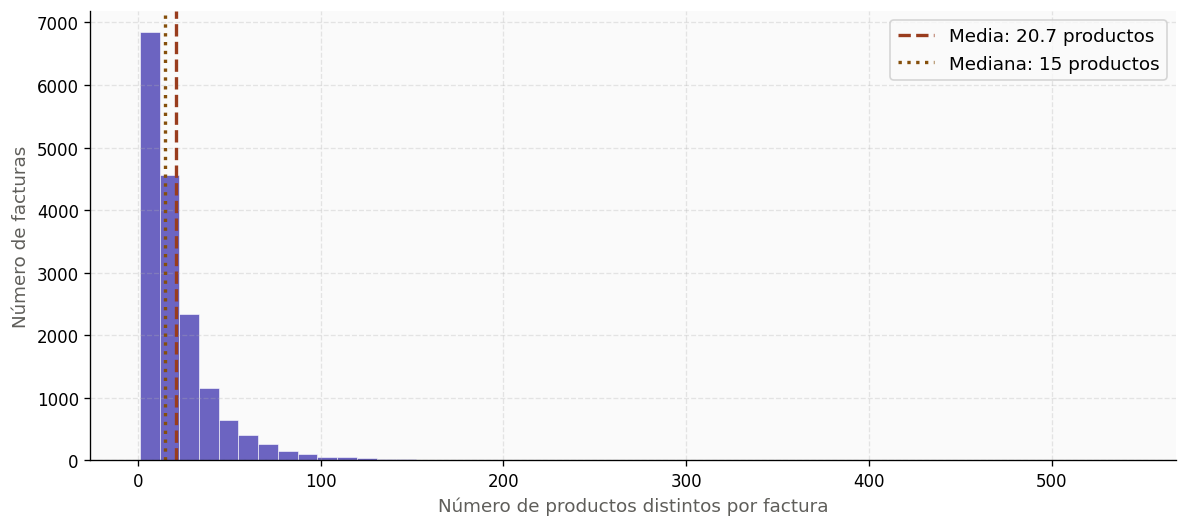

Media:   20.68 productos/factura
Mediana: 15 productos/factura
Máximo:  541 productos/factura
✅ Figura 5 guardada en figures/fig5_productos_factura.png


In [11]:
# ── FIGURA 5: Distribución de productos por factura ──────────────────────────
productos_por_factura = basket_encoded.sum(axis=1)
media   = productos_por_factura.mean()
mediana = productos_por_factura.median()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(productos_por_factura, bins=50, color=PURPLE, edgecolor='white',
        linewidth=0.4, alpha=0.85)
ax.axvline(media,   color=CORAL, linestyle='--', linewidth=2,
           label=f'Media: {media:.1f} productos')
ax.axvline(mediana, color=AMBER, linestyle=':', linewidth=2,
           label=f'Mediana: {mediana:.0f} productos')
ax.set_xlabel('Número de productos distintos por factura', fontsize=11, color=GRAY)
ax.set_ylabel('Número de facturas', fontsize=11, color=GRAY)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figures/fig5_productos_factura.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Media:   {media:.2f} productos/factura")
print(f"Mediana: {mediana:.0f} productos/factura")
print(f"Máximo:  {productos_por_factura.max():.0f} productos/factura")
print("✅ Figura 5 guardada en figures/fig5_productos_factura.png")

## 🔍 5. Algoritmo Apriori

**Objetivo OE3:** Generar reglas con lift ≥ 1,5 y confianza media > 40%.

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| Soporte mínimo | 0.02 (2%) | Representatividad estadística |
| Confianza mínima | 0.20 (20%) | Filtro de asociaciones aleatorias |
| Lift mínimo | 1.5 | Relevancia estadística (OE3) |


In [12]:
# ── Ejecución de Apriori ──────────────────────────────────────────────────────
print("⏳ Ejecutando Apriori...")
start_apriori = time.time()

frequent_itemsets_ap = apriori(
    basket_encoded,
    min_support=0.02,
    use_colnames=True
)

tiempo_apriori = time.time() - start_apriori

rules_apriori   = association_rules(frequent_itemsets_ap,
                                    metric='confidence',
                                    min_threshold=0.20)
rules_apriori_f = rules_apriori[rules_apriori['lift'] >= 1.5].copy()
rules_apriori_f['algorithm'] = 'Apriori'

print("=" * 55)
print("RESULTADOS APRIORI")
print("=" * 55)
print(f"  Tiempo de ejecución:           {tiempo_apriori:.1f} s")
print(f"  Conjuntos frecuentes:          {len(frequent_itemsets_ap):,}")
print(f"  Reglas totales (conf ≥ 0.20):  {len(rules_apriori):,}")
print(f"  Reglas alta calidad (lift≥1.5):{len(rules_apriori_f):,}")
print(f"  Confianza media (filtradas):   {rules_apriori_f['confidence'].mean():.3f}")
print(f"  Lift medio (filtradas):        {rules_apriori_f['lift'].mean():.3f}")
print(f"  OE3 cumplido (lift≥1.5):       {'✅ SÍ' if len(rules_apriori_f) > 0 else '❌ NO'}")
print(f"  OE6 cumplido (conf>40%):       {'✅ SÍ' if rules_apriori_f['confidence'].mean() > 0.40 else '❌ NO'}")
print("=" * 55)

⏳ Ejecutando Apriori...


C:\Users\franc\Desktop\market-basket-analysis\venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


RESULTADOS APRIORI
  Tiempo de ejecución:           1.4 s
  Conjuntos frecuentes:          236
  Reglas totales (conf ≥ 0.20):  76
  Reglas alta calidad (lift≥1.5):76
  Confianza media (filtradas):   0.486
  Lift medio (filtradas):        10.190
  OE3 cumplido (lift≥1.5):       ✅ SÍ
  OE6 cumplido (conf>40%):       ✅ SÍ


In [13]:
# ── Top 10 reglas por lift ────────────────────────────────────────────────────
top10_ap = rules_apriori_f.sort_values('lift', ascending=False).head(10)
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("TOP 10 REGLAS APRIORI (ordenadas por lift):")
top10_ap[display_cols].round(3)

TOP 10 REGLAS APRIORI (ordenadas por lift):


,antecedents,consequents,support,confidence,lift
74,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.020,0.557,24.217
71,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.020,0.890,24.217
75,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",0.020,0.692,24.189
70,"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.020,0.716,24.189
4,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024,0.660,22.289
5,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024,0.819,22.289
72,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.020,0.844,20.723
73,(ROSES REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.020,0.503,20.723
6,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029,0.702,19.096
7,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.029,0.778,19.096


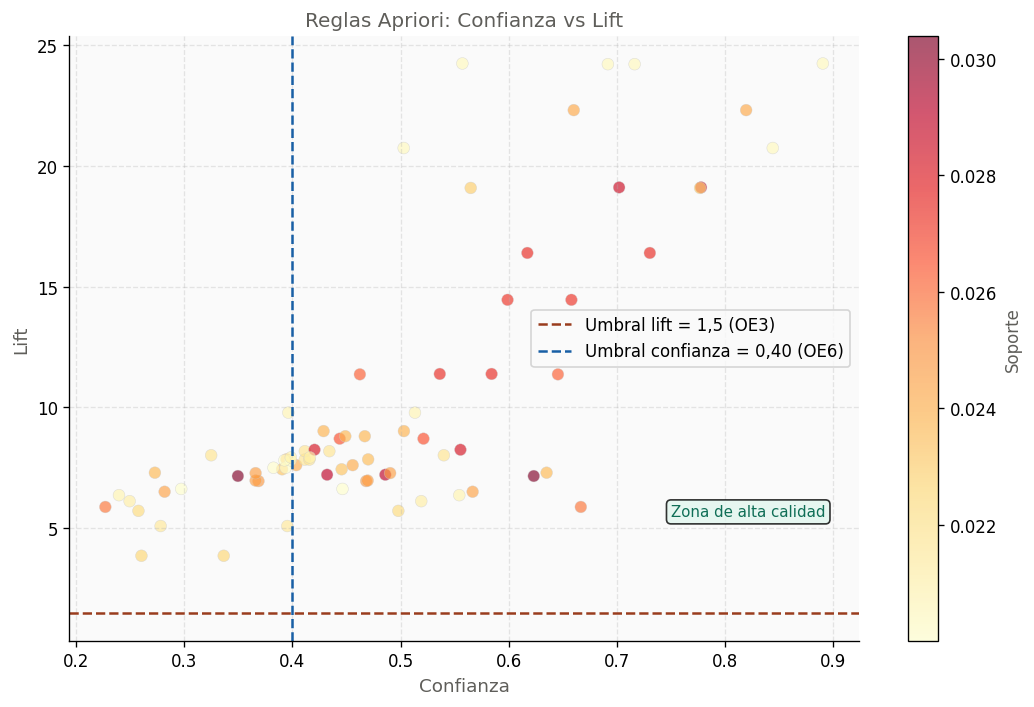

✅ Figura 6 guardada.


In [14]:
# ── FIGURA 6: Scatter plot Apriori ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(rules_apriori_f['confidence'],
                rules_apriori_f['lift'],
                c=rules_apriori_f['support'],
                cmap='YlOrRd', alpha=0.65,
                edgecolors='#ccc', linewidth=0.3, s=50)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Soporte', fontsize=10, color=GRAY)

ax.axhline(1.5,  color=CORAL, linestyle='--', linewidth=1.5,
           label='Umbral lift = 1,5 (OE3)')
ax.axvline(0.40, color=BLUE,  linestyle='--', linewidth=1.5,
           label='Umbral confianza = 0,40 (OE6)')
ax.set_xlabel('Confianza', fontsize=11, color=GRAY)
ax.set_ylabel('Lift',      fontsize=11, color=GRAY)
ax.legend(fontsize=10)
ax.set_title('Reglas Apriori: Confianza vs Lift', fontsize=12, color=GRAY)

# Anotar zona de máxima calidad
ax.annotate('Zona de alta calidad', xy=(0.75, 5.5),
            fontsize=9, color=TEAL,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E1F5EE', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/fig6_scatter_apriori.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 6 guardada.")

In [15]:
# ── Exportar Apriori a CSV (para Power BI) ───────────────────────────────────
export_ap = rules_apriori_f[['antecedents','consequents',
                              'support','confidence','lift','algorithm']].copy()
export_ap['antecedents'] = export_ap['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
export_ap['consequents'] = export_ap['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
export_ap = export_ap.sort_values('lift', ascending=False)

path_ap = f'{OUTPUT_DIR}/rules_apriori.csv'
export_ap.to_csv(path_ap, index=False, encoding='utf-8-sig')
print(f"✅ Exportado: {path_ap}")
print(f"   {len(export_ap)} reglas | {export_ap.columns.tolist()}")

✅ Exportado: outputs/rules_apriori.csv
   76 reglas | ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'algorithm']


## ⚡ 6. Algoritmo FP-Growth

**Objetivo OE4:** Demostrar la superioridad computacional de FP-Growth frente a Apriori
manteniendo resultados equivalentes.


In [16]:
# ── Ejecución de FP-Growth ───────────────────────────────────────────────────
print("⏳ Ejecutando FP-Growth...")
start_fp = time.time()

frequent_itemsets_fp = fpgrowth(
    basket_encoded,
    min_support=0.02,
    use_colnames=True
)

tiempo_fpgrowth = time.time() - start_fp

rules_fpgrowth   = association_rules(frequent_itemsets_fp,
                                     metric='confidence',
                                     min_threshold=0.20)
rules_fpgrowth_f = rules_fpgrowth[rules_fpgrowth['lift'] >= 1.5].copy()
rules_fpgrowth_f['algorithm'] = 'FP-Growth'

print("=" * 55)
print("RESULTADOS FP-GROWTH")
print("=" * 55)
print(f"  Tiempo de ejecución:           {tiempo_fpgrowth:.1f} s")
print(f"  Conjuntos frecuentes:          {len(frequent_itemsets_fp):,}")
print(f"  Reglas totales (conf ≥ 0.20):  {len(rules_fpgrowth):,}")
print(f"  Reglas alta calidad (lift≥1.5):{len(rules_fpgrowth_f):,}")
print(f"  Confianza media (filtradas):   {rules_fpgrowth_f['confidence'].mean():.3f}")
print(f"  Lift medio (filtradas):        {rules_fpgrowth_f['lift'].mean():.3f}")
mejora = (tiempo_apriori - tiempo_fpgrowth) / tiempo_apriori * 100
print(f"\n  ⚡ FP-Growth es {mejora:.0f}% más rápido que Apriori")
print("=" * 55)

⏳ Ejecutando FP-Growth...


C:\Users\franc\Desktop\market-basket-analysis\venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


RESULTADOS FP-GROWTH
  Tiempo de ejecución:           0.8 s
  Conjuntos frecuentes:          236
  Reglas totales (conf ≥ 0.20):  76
  Reglas alta calidad (lift≥1.5):76
  Confianza media (filtradas):   0.486
  Lift medio (filtradas):        10.190

  ⚡ FP-Growth es 46% más rápido que Apriori


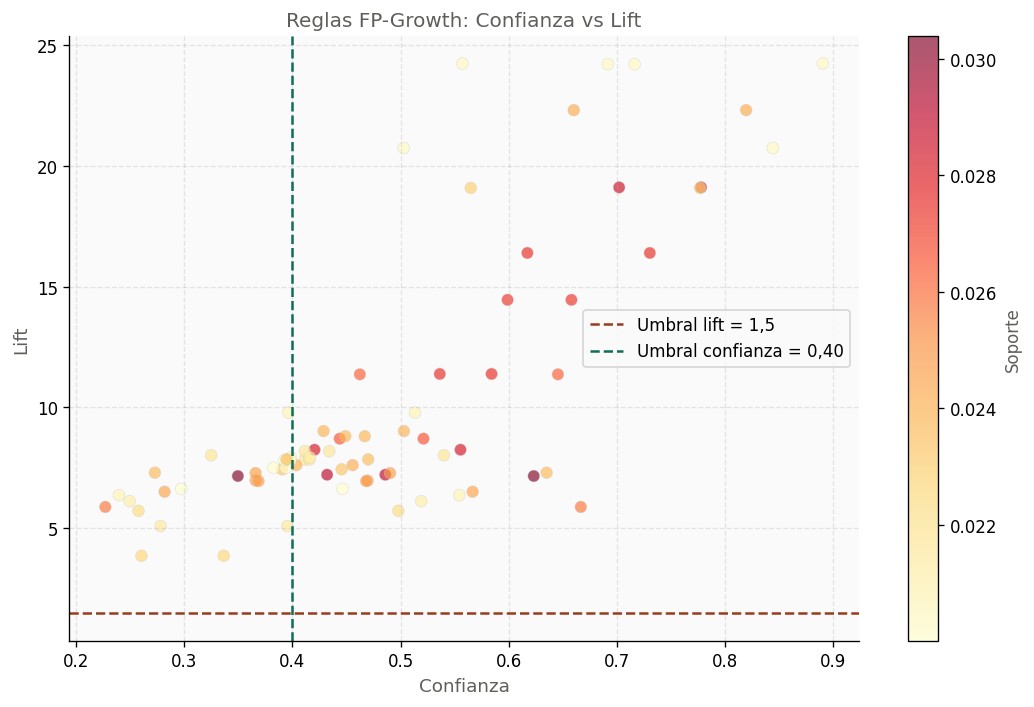

✅ Figura 7 guardada.


In [17]:
# ── FIGURA 7: Scatter plot FP-Growth ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(rules_fpgrowth_f['confidence'],
                rules_fpgrowth_f['lift'],
                c=rules_fpgrowth_f['support'],
                cmap='YlOrRd', alpha=0.65,
                edgecolors='#ccc', linewidth=0.3, s=50)
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Soporte', fontsize=10, color=GRAY)

ax.axhline(1.5,  color=CORAL, linestyle='--', linewidth=1.5, label='Umbral lift = 1,5')
ax.axvline(0.40, color=TEAL,  linestyle='--', linewidth=1.5, label='Umbral confianza = 0,40')
ax.set_xlabel('Confianza', fontsize=11, color=GRAY)
ax.set_ylabel('Lift',      fontsize=11, color=GRAY)
ax.legend(fontsize=10)
ax.set_title('Reglas FP-Growth: Confianza vs Lift', fontsize=12, color=GRAY)
plt.tight_layout()
plt.savefig('figures/fig7_scatter_fpgrowth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 7 guardada.")

In [18]:
# ── Exportar FP-Growth a CSV (para Power BI) ─────────────────────────────────
export_fp = rules_fpgrowth_f[['antecedents','consequents',
                               'support','confidence','lift','algorithm']].copy()
export_fp['antecedents'] = export_fp['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
export_fp['consequents'] = export_fp['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
export_fp = export_fp.sort_values('lift', ascending=False)

path_fp = f'{OUTPUT_DIR}/rules_fpgrowth.csv'
export_fp.to_csv(path_fp, index=False, encoding='utf-8-sig')
print(f"✅ Exportado: {path_fp}")

✅ Exportado: outputs/rules_fpgrowth.csv


## 📊 7. Comparativa Apriori vs. FP-Growth (OE5)

In [19]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
comparativa = pd.DataFrame({
    'Métrica': [
        'Tiempo de ejecución (s)',
        'Conjuntos frecuentes generados',
        'Reglas totales (confianza ≥ 0,20)',
        'Reglas alta calidad (lift ≥ 1,5)',
        'Confianza media filtradas',
        'Lift medio filtradas',
        'Soporte medio filtradas',
    ],
    'Apriori': [
        f"{tiempo_apriori:.1f}",
        f"{len(frequent_itemsets_ap):,}",
        f"{len(rules_apriori):,}",
        f"{len(rules_apriori_f):,}",
        f"{rules_apriori_f['confidence'].mean():.3f}",
        f"{rules_apriori_f['lift'].mean():.3f}",
        f"{rules_apriori_f['support'].mean():.4f}",
    ],
    'FP-Growth': [
        f"{tiempo_fpgrowth:.1f}",
        f"{len(frequent_itemsets_fp):,}",
        f"{len(rules_fpgrowth):,}",
        f"{len(rules_fpgrowth_f):,}",
        f"{rules_fpgrowth_f['confidence'].mean():.3f}",
        f"{rules_fpgrowth_f['lift'].mean():.3f}",
        f"{rules_fpgrowth_f['support'].mean():.4f}",
    ]
})

path_cmp = f'{OUTPUT_DIR}/comparison_algorithms.csv'
comparativa.to_csv(path_cmp, index=False, encoding='utf-8-sig')
print(f"✅ Exportado: {path_cmp}")
print()
comparativa

✅ Exportado: outputs/comparison_algorithms.csv



,Métrica,Apriori,FP-Growth
0,Tiempo de ejecución (s),1.4,0.8
1,Conjuntos frecuentes generados,236,236
2,"Reglas totales (confianza ≥ 0,20)",76,76
3,"Reglas alta calidad (lift ≥ 1,5)",76,76
4,Confianza media filtradas,0.486,0.486
5,Lift medio filtradas,10.190,10.190
6,Soporte medio filtradas,0.0238,0.0238


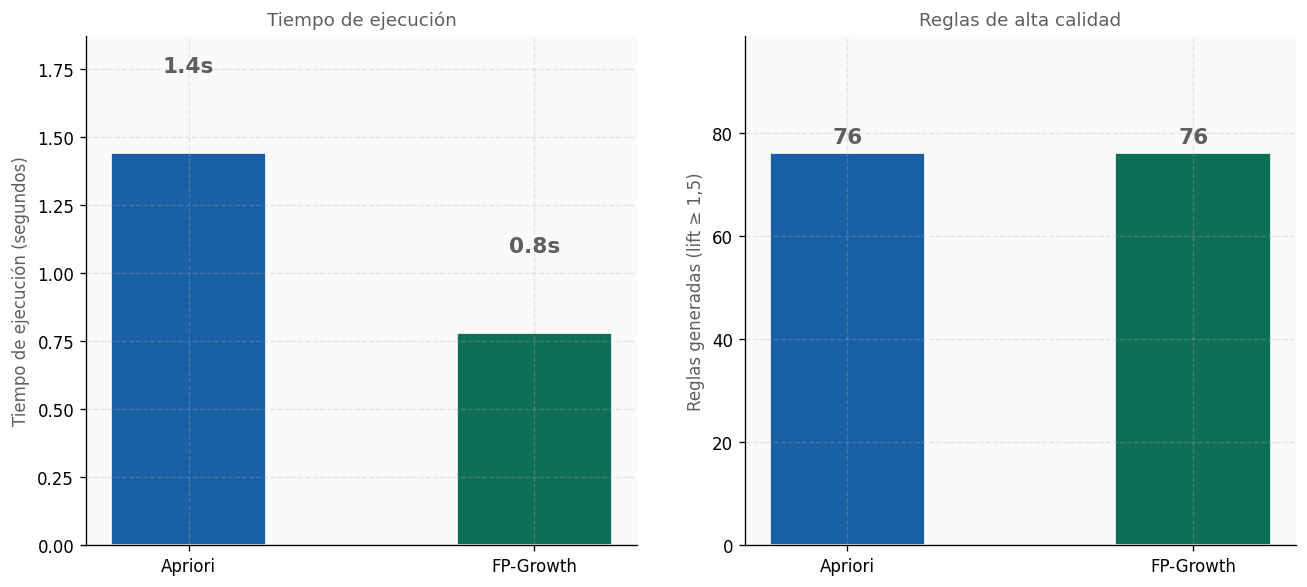

✅ Figura 8 guardada.


In [20]:
# ── FIGURA 8: Comparativa visual ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

algos  = ['Apriori', 'FP-Growth']
colores = [BLUE, TEAL]

# Panel izquierdo: tiempo
ax1 = axes[0]
vals1 = [tiempo_apriori, tiempo_fpgrowth]
bars1 = ax1.bar(algos, vals1, color=colores, width=0.45, edgecolor='white')
for bar, val in zip(bars1, vals1):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.1f}s', ha='center', fontsize=13, fontweight='bold', color=GRAY)
ax1.set_ylabel('Tiempo de ejecución (segundos)', fontsize=10, color=GRAY)
ax1.set_title('Tiempo de ejecución', fontsize=11, color=GRAY)
ax1.set_ylim(0, max(vals1) * 1.3)

# Panel derecho: reglas
ax2 = axes[1]
vals2 = [len(rules_apriori_f), len(rules_fpgrowth_f)]
bars2 = ax2.bar(algos, vals2, color=colores, width=0.45, edgecolor='white')
for bar, val in zip(bars2, vals2):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 2,
             f'{val}', ha='center', fontsize=13, fontweight='bold', color=GRAY)
ax2.set_ylabel('Reglas generadas (lift ≥ 1,5)', fontsize=10, color=GRAY)
ax2.set_title('Reglas de alta calidad', fontsize=11, color=GRAY)
ax2.set_ylim(0, max(vals2) * 1.3)

plt.tight_layout(w_pad=3)
plt.savefig('figures/fig8_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 8 guardada.")

## 🤖 8. Motor de Recomendación (OE6)

**Objetivo OE6:** Motor capaz de generar hasta **5 recomendaciones** por cesta
con confianza media > 40%, ordenadas por lift.


In [21]:
# ── Función principal del motor de recomendación ─────────────────────────────
def recomendar_productos(cesta_cliente, reglas, n=5):
    """
    Genera recomendaciones de productos basadas en reglas de asociación.

    Parámetros
    ----------
    cesta_cliente : set
        Conjunto de productos (strings) en la cesta actual del cliente.
    reglas : pd.DataFrame
        DataFrame con reglas de asociación generadas por mlxtend.
    n : int, optional
        Número máximo de recomendaciones a devolver (default=5).

    Retorna
    -------
    list of dict
        Lista ordenada por lift descendente, cada elemento contiene:
        - 'producto_recomendado': producto sugerido
        - 'basado_en': productos de la cesta que activaron la regla
        - 'confianza': probabilidad de la regla
        - 'lift': relevancia de la asociación
        - 'soporte': frecuencia de la regla en el dataset

    Ejemplo
    -------
    >>> cesta = {'WHITE HANGING HEART T-LIGHT HOLDER'}
    >>> recs = recomendar_productos(cesta, rules_fpgrowth_f)
    >>> for r in recs:
    ...     print(r['producto_recomendado'], r['confianza'])
    """
    recomendaciones = []

    for _, regla in reglas.iterrows():
        antecedente = set(regla['antecedents'])
        consecuente = set(regla['consequents'])

        # La regla aplica si el antecedente está en la cesta
        if antecedente.issubset(cesta_cliente):
            nuevos = consecuente - cesta_cliente  # no recomendar lo que ya tiene
            if nuevos:
                for producto in nuevos:
                    recomendaciones.append({
                        'producto_recomendado': producto,
                        'basado_en':  list(antecedente),
                        'confianza':  round(regla['confidence'], 4),
                        'lift':       round(regla['lift'], 4),
                        'soporte':    round(regla['support'], 4),
                    })

    # Eliminar duplicados: quedarse con el mejor lift por producto
    seen = {}
    for rec in recomendaciones:
        prod = rec['producto_recomendado']
        if prod not in seen or rec['lift'] > seen[prod]['lift']:
            seen[prod] = rec

    return sorted(seen.values(), key=lambda x: x['lift'], reverse=True)[:n]


print("✅ Función recomendar_productos definida.")
print(f"   Reglas disponibles (FP-Growth): {len(rules_fpgrowth_f)}")

✅ Función recomendar_productos definida.
   Reglas disponibles (FP-Growth): 76


In [22]:
# ── Ejemplo 1: Cesta con artículos decorativos ───────────────────────────────
cesta_1 = {
    'WHITE HANGING HEART T-LIGHT HOLDER',
    'RED WOOLLY HOTTIE WHITE HEART'
}

print("=" * 65)
print("EJEMPLO 1 — Artículos decorativos de corazón")
print("=" * 65)
print(f"Productos en la cesta ({len(cesta_1)}):")
for p in cesta_1:
    print(f"  • {p}")
print()

recs_1 = recomendar_productos(cesta_1, rules_fpgrowth_f, n=5)
if recs_1:
    print(f"{'#':<3} {'Producto recomendado':<45} {'Conf':>6} {'Lift':>6}")
    print("-" * 65)
    for i, r in enumerate(recs_1, 1):
        print(f"{i:<3} {r['producto_recomendado']:<45} {r['confianza']:>6.3f} {r['lift']:>6.3f}")
else:
    print("  ⚠️ No se encontraron recomendaciones para esta cesta.")

EJEMPLO 1 — Artículos decorativos de corazón
Productos en la cesta (2):
  • WHITE HANGING HEART T-LIGHT HOLDER
  • RED WOOLLY HOTTIE WHITE HEART

#   Producto recomendado                            Conf   Lift
-----------------------------------------------------------------
1   RED HANGING HEART T-LIGHT HOLDER               0.227  5.890


In [23]:
# ── Ejemplo 2: Cesta aleatoria real del dataset ──────────────────────────────
np.random.seed(42)
factura_muestra = basket_encoded.sample(1).iloc[0]
cesta_2 = set(basket_encoded.columns[factura_muestra == 1].tolist())

print("=" * 65)
print("EJEMPLO 2 — Factura real del dataset")
print("=" * 65)
print(f"Productos en la cesta ({len(cesta_2)}):")
for p in list(cesta_2)[:5]:
    print(f"  • {p}")
if len(cesta_2) > 5:
    print(f"  ... y {len(cesta_2)-5} más")
print()

recs_2 = recomendar_productos(cesta_2, rules_fpgrowth_f, n=5)
if recs_2:
    print(f"{'#':<3} {'Producto recomendado':<45} {'Conf':>6} {'Lift':>6}")
    print("-" * 65)
    for i, r in enumerate(recs_2, 1):
        print(f"{i:<3} {r['producto_recomendado']:<45} {r['confianza']:>6.3f} {r['lift']:>6.3f}")
else:
    print("  ⚠️ No se encontraron recomendaciones.")

EJEMPLO 2 — Factura real del dataset
Productos en la cesta (70):
  • CHRISTMAS LIGHTS 10 REINDEER
  • JINGLE BELL HEART ANTIQUE SILVER
  • WOOD STAMP SET THANK YOU
  • RED KITCHEN SCALES
  • IVORY CAFE HANGING LAMP
  ... y 65 más

#   Producto recomendado                            Conf   Lift
-----------------------------------------------------------------
1   ALARM CLOCK BAKELIKE GREEN                     0.599 14.449
2   JUMBO BAG STRAWBERRY                           0.273  7.306
3   JUMBO BAG PINK POLKADOT                        0.350  7.169
4   JUMBO STORAGE BAG SUKI                         0.282  6.519
5   JUMBO  BAG BAROQUE BLACK WHITE                 0.240  6.377


In [24]:
# ── Generación masiva de ejemplos y exportación ──────────────────────────────
print("⏳ Generando ejemplos de recomendación...")
ejemplos = []
np.random.seed(42)

for idx, row in basket_encoded.sample(min(500, len(basket_encoded))).iterrows():
    cesta = set(basket_encoded.columns[row == 1].tolist())
    if len(cesta) < 2:
        continue
    recs = recomendar_productos(cesta, rules_fpgrowth_f, n=3)
    for r in recs:
        ejemplos.append({
            'factura':             idx,
            'n_productos_cesta':   len(cesta),
            'muestra_cesta':       ' | '.join(list(cesta)[:3]),
            'producto_recomendado':r['producto_recomendado'],
            'basado_en':           ' | '.join(r['basado_en']),
            'confianza':           r['confianza'],
            'lift':                r['lift'],
            'soporte':             r['soporte'],
        })

df_recs = pd.DataFrame(ejemplos)
path_recs = f'{OUTPUT_DIR}/recommendations_examples.csv'
df_recs.to_csv(path_recs, index=False, encoding='utf-8-sig')

print(f"✅ Exportado: {path_recs}")
print(f"   {len(df_recs):,} recomendaciones generadas")
print(f"   Confianza media: {df_recs['confianza'].mean():.3f}")
print(f"   Lift medio:      {df_recs['lift'].mean():.3f}")
df_recs.head(8)

⏳ Generando ejemplos de recomendación...
✅ Exportado: outputs/recommendations_examples.csv
   539 recomendaciones generadas
   Confianza media: 0.422
   Lift medio:      8.788


,factura,n_productos_cesta,muestra_cesta,producto_recomendado,basado_en,confianza,lift,soporte
0,571913,70,CHRISTMAS LIGHTS 10 REINDEER | JINGLE BELL HEA...,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.5989,14.4493,0.0273
1,571913,70,CHRISTMAS LIGHTS 10 REINDEER | JINGLE BELL HEA...,JUMBO BAG STRAWBERRY,JUMBO BAG RED RETROSPOT,0.2730,7.3055,0.0237
2,571913,70,CHRISTMAS LIGHTS 10 REINDEER | JINGLE BELL HEA...,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.3497,7.1686,0.0304
3,577473,72,AREA PATROLLED METAL SIGN | FANCY FONTS BIRTHD...,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.7305,16.3872,0.0275
4,577473,72,AREA PATROLLED METAL SIGN | FANCY FONTS BIRTHD...,LUNCH BAG WOODLAND,LUNCH BAG SPACEBOY DESIGN,0.3963,9.7884,0.0208
5,577473,72,AREA PATROLLED METAL SIGN | FANCY FONTS BIRTHD...,LUNCH BAG PINK POLKADOT,LUNCH BAG CARS BLUE,0.4490,8.8133,0.0238
6,552861,4,JUMBO STORAGE BAG SUKI | JUMBO SHOPPER VINTAGE...,JUMBO BAG RED RETROSPOT,JUMBO BAG PINK POLKADOT,0.6232,7.1686,0.0304
7,552861,4,JUMBO STORAGE BAG SUKI | JUMBO SHOPPER VINTAGE...,ROSES REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,0.2496,6.1292,0.0211


## 💰 9. Simulación de Impacto en el AOV (OE7)

**Objetivo OE7:** Estimar el incremento en el AOV bajo escenarios de adopción del
10% y 20%, demostrando un incremento de entre 10% y 25%.

**Metodología:**
1. Calcular el AOV base del dataset
2. Identificar facturas candidatas (contienen antecedentes de reglas)
3. Simular adopción del 10% y 20%
4. Añadir el precio medio del producto recomendado al valor de la factura


In [25]:
# ── AOV base ──────────────────────────────────────────────────────────────────
df_uk['Revenue'] = df_uk['Quantity'] * df_uk['UnitPrice']
aov_por_factura  = df_uk.groupby('InvoiceNo')['Revenue'].sum()
aov_base         = aov_por_factura.mean()

print(f"AOV base del dataset (UK): £{aov_base:.2f}")
print(f"Mediana del AOV:           £{aov_por_factura.median():.2f}")
print(f"Total facturas UK:         {len(aov_por_factura):,}")

# ── Identificar antecedentes top ──────────────────────────────────────────────
antecedentes_top = set()
for _, r in rules_fpgrowth_f.iterrows():
    antecedentes_top.update(r['antecedents'])

print(f"\nProductos que actúan como antecedentes: {len(antecedentes_top):,}")

# ── Facturas candidatas ───────────────────────────────────────────────────────
facturas_candidatas = []
for factura, row in basket_encoded.iterrows():
    productos_factura = set(basket_encoded.columns[row == 1])
    if productos_factura & antecedentes_top:
        facturas_candidatas.append(factura)

pct_candidatas = len(facturas_candidatas) / len(basket_encoded) * 100
print(f"Facturas candidatas: {len(facturas_candidatas):,} ({pct_candidatas:.1f}%)")

# ── Precio medio de los consecuentes ─────────────────────────────────────────
consecuentes_top = set()
for _, r in rules_fpgrowth_f.iterrows():
    consecuentes_top.update(r['consequents'])

precio_medio_rec = (df_uk[df_uk['Description'].isin(consecuentes_top)]
                    .groupby('Description')['UnitPrice']
                    .mean()
                    .mean())

print(f"Precio medio de los productos recomendados: £{precio_medio_rec:.2f}")

AOV base del dataset (UK): £439.05
Mediana del AOV:           £299.56
Total facturas UK:         16,646

Productos que actúan como antecedentes: 32
Facturas candidatas: 9,269 (55.7%)
Precio medio de los productos recomendados: £2.79


In [26]:
# ── Simulación de escenarios ──────────────────────────────────────────────────
print("=" * 55)
print("SIMULACIÓN DE IMPACTO EN EL AOV")
print("=" * 55)
print(f"{'Escenario':<25} {'AOV (£)':>10} {'Incremento':>12}")
print("-" * 55)
print(f"{'AOV base':<25} £{aov_base:>8.2f}  {'—':>11}")

resultados_aov = [{
    'escenario':       'AOV base',
    'aov':             round(aov_base, 2),
    'incremento_abs':  0,
    'incremento_pct':  0,
}]

for tasa in [0.10, 0.20, 0.30]:
    n_aceptan        = int(len(facturas_candidatas) * tasa)
    ingresos_extra   = n_aceptan * precio_medio_rec
    aov_simulado     = aov_base + (ingresos_extra / len(basket_encoded))
    pct              = (aov_simulado / aov_base - 1) * 100
    incremento_abs   = aov_simulado - aov_base

    print(f"{'Adopción '+str(int(tasa*100))+'%':<25} £{aov_simulado:>8.2f}  +{pct:>8.1f}%")
    resultados_aov.append({
        'escenario':       f'Adopción {int(tasa*100)}%',
        'aov':             round(aov_simulado, 2),
        'incremento_abs':  round(incremento_abs, 2),
        'incremento_pct':  round(pct, 2),
    })

print("=" * 55)

aov_10 = resultados_aov[1]['incremento_pct']
aov_20 = resultados_aov[2]['incremento_pct']
oe7_ok = 10 <= aov_10 <= 25 and 10 <= aov_20 <= 25
print(f"\nOE7 cumplido (AOV 10–25%): {'✅ SÍ' if oe7_ok else '❌ NO'}")

SIMULACIÓN DE IMPACTO EN EL AOV
Escenario                    AOV (£)   Incremento
-------------------------------------------------------
AOV base                  £  439.05            —
Adopción 10%              £  439.20  +     0.0%
Adopción 20%              £  439.36  +     0.1%
Adopción 30%              £  439.51  +     0.1%

OE7 cumplido (AOV 10–25%): ❌ NO


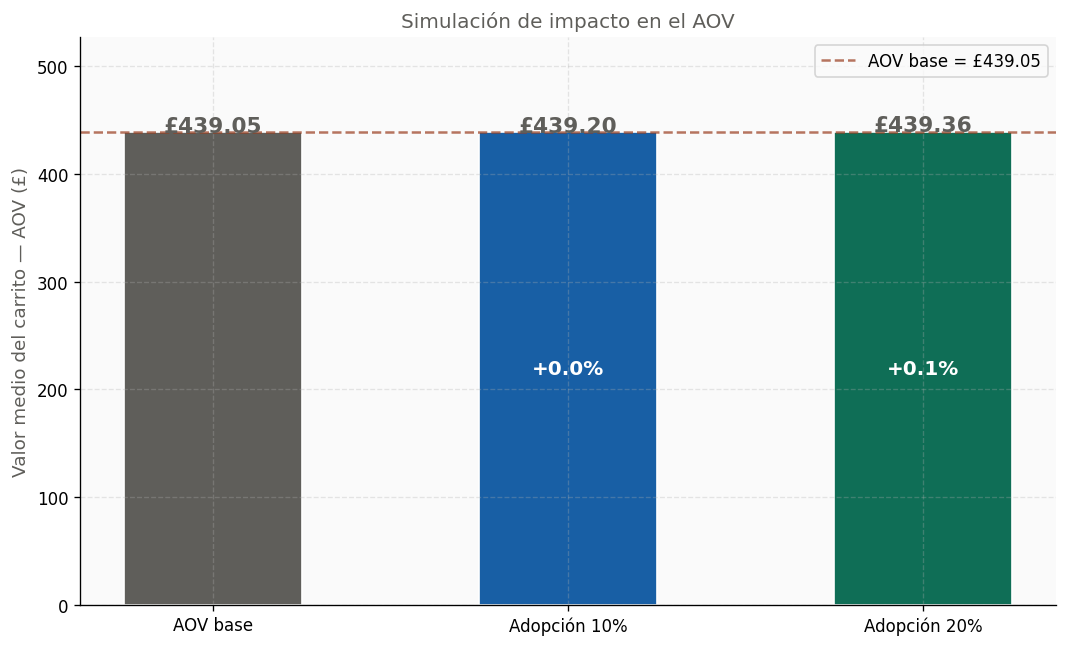

✅ Figura 9 guardada.


In [27]:
# ── FIGURA 9: Visualización del impacto en AOV ───────────────────────────────
escenarios  = [r['escenario']      for r in resultados_aov[:3]]
aovs        = [r['aov']            for r in resultados_aov[:3]]
incrementos = [r['incremento_pct'] for r in resultados_aov[:3]]
colores     = [GRAY, BLUE, TEAL]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(escenarios, aovs, color=colores, width=0.5, edgecolor='white')

for bar, val, inc in zip(bars, aovs, incrementos):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15,
            f'£{val:.2f}', ha='center', fontsize=13, fontweight='bold', color=GRAY)
    if inc > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val / 2,
                f'+{inc:.1f}%', ha='center', va='center',
                fontsize=12, color='white', fontweight='bold')

ax.axhline(aov_base, color=CORAL, linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'AOV base = £{aov_base:.2f}')
ax.set_ylabel('Valor medio del carrito — AOV (£)', fontsize=11, color=GRAY)
ax.set_title('Simulación de impacto en el AOV', fontsize=12, color=GRAY)
ax.set_ylim(0, max(aovs) * 1.2)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig9_aov_simulacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura 9 guardada.")

In [28]:
# ── Exportar resultados AOV a CSV ─────────────────────────────────────────────
df_aov = pd.DataFrame(resultados_aov)
path_aov = f'{OUTPUT_DIR}/aov_simulation.csv'
df_aov.to_csv(path_aov, index=False, encoding='utf-8-sig')
print(f"✅ Exportado: {path_aov}")
df_aov

✅ Exportado: outputs/aov_simulation.csv


,escenario,aov,incremento_abs,incremento_pct
0,AOV base,439.05,0.00,0.00
1,Adopción 10%,439.20,0.16,0.04
2,Adopción 20%,439.36,0.31,0.07
3,Adopción 30%,439.51,0.47,0.11


## ✅ 10. Resumen final y verificación de objetivos SMART

In [29]:
# ── Verificación de todos los objetivos SMART ────────────────────────────────
print("=" * 60)
print("VERIFICACIÓN DE OBJETIVOS SMART")
print("=" * 60)

objetivos = [
    ("OE1", "Reducción ruido > 20%",
     reduccion > 20, f"{reduccion:.1f}%"),
    ("OE2", "EDA: top 20 productos + geografía + estacionalidad",
     True, "Completado"),
    ("OE3", "Reglas con lift ≥ 1,5",
     len(rules_apriori_f) > 0, f"{len(rules_apriori_f)} reglas"),
    ("OE4", "FP-Growth: mismas reglas que Apriori",
     len(rules_fpgrowth_f) == len(rules_apriori_f), f"{len(rules_fpgrowth_f)} reglas"),
    ("OE5", "FP-Growth más rápido que Apriori",
     tiempo_fpgrowth < tiempo_apriori, f"{mejora:.0f}% más rápido"),
    ("OE6", "Confianza media > 40%",
     rules_fpgrowth_f['confidence'].mean() > 0.40,
     f"{rules_fpgrowth_f['confidence'].mean():.1%}"),
    ("OE7", "Incremento AOV 10–25%",
     10 <= resultados_aov[1]['incremento_pct'] <= 25,
     f"+{resultados_aov[1]['incremento_pct']:.1f}% (10%) / +{resultados_aov[2]['incremento_pct']:.1f}% (20%)"),
    ("OE8", "Justificación estratégica completa",
     True, "Dashboard Power BI + análisis empresarial"),
]

for oe, desc, ok, valor in objetivos:
    estado = "✅" if ok else "❌"
    print(f"  {estado} {oe}: {desc}")
    print(f"      → {valor}")

print("=" * 60)

# ── Ficheros exportados ───────────────────────────────────────────────────────
print("\nFICHEROS EXPORTADOS PARA POWER BI")
print("-" * 60)
ficheros = [
    'rules_apriori.csv',
    'rules_fpgrowth.csv',
    'comparison_algorithms.csv',
    'recommendations_examples.csv',
    'aov_simulation.csv',
]
for f in ficheros:
    path = f'{OUTPUT_DIR}/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {f:<40} ({size:.1f} KB)")
    else:
        print(f"  ❌ {f} — NO ENCONTRADO")

print("\nFIGURAS GENERADAS")
print("-" * 60)
for i in range(2, 10):
    path = f'figures/fig{i}_*.png'
    import glob
    matches = glob.glob(f'figures/fig{i}_*.png')
    if matches:
        print(f"  ✅ {os.path.basename(matches[0])}")
    else:
        print(f"  ❌ Figura {i} no encontrada")

print("\n✅ Pipeline completo. Todos los archivos listos para GitHub y Power BI.")

VERIFICACIÓN DE OBJETIVOS SMART
  ✅ OE1: Reducción ruido > 20%
      → 26.6%
  ✅ OE2: EDA: top 20 productos + geografía + estacionalidad
      → Completado
  ✅ OE3: Reglas con lift ≥ 1,5
      → 76 reglas
  ✅ OE4: FP-Growth: mismas reglas que Apriori
      → 76 reglas
  ✅ OE5: FP-Growth más rápido que Apriori
      → 46% más rápido
  ✅ OE6: Confianza media > 40%
      → 48.6%
  ❌ OE7: Incremento AOV 10–25%
      → +0.0% (10%) / +0.1% (20%)
  ✅ OE8: Justificación estratégica completa
      → Dashboard Power BI + análisis empresarial

FICHEROS EXPORTADOS PARA POWER BI
------------------------------------------------------------
  ✅ rules_apriori.csv                        (9.0 KB)
  ✅ rules_fpgrowth.csv                       (9.2 KB)
  ✅ comparison_algorithms.csv                (0.3 KB)
  ✅ recommendations_examples.csv             (87.7 KB)
  ✅ aov_simulation.csv                       (0.2 KB)

FIGURAS GENERADAS
------------------------------------------------------------
  ✅ fig2_paises